<a href="https://colab.research.google.com/github/Atherizz/PCVK_Genap_2026/blob/main/week_2/tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import cv2 as cv
import matplotlib.pylab as plt

drive.mount('/content/drive')
foto = cv.imread("/content/drive/MyDrive/berkas/foto_aktivitas.jpg")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


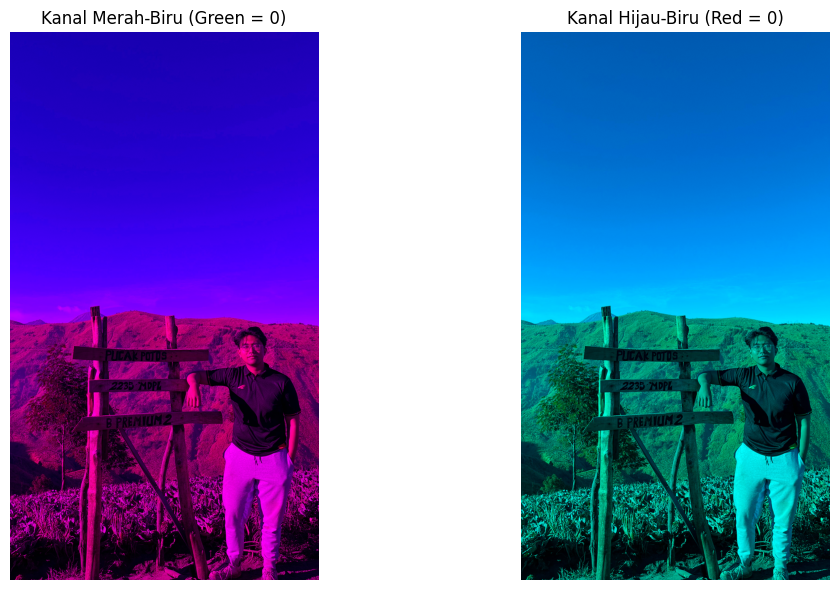

In [ ]:
# Konversi ke RGB untuk visualisasi Matplotlib
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)

# 1. Kanal Merah-Biru (kanal Hijau/index 1 dinolkan)
img_rb = foto_rgb.copy()
img_rb[:, :, 1] = 0

# 2. Kanal Hijau-Biru (kanal Merah/index 0 dinolkan)
img_gb = foto_rgb.copy()
img_gb[:, :, 0] = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rb)
axes[0].set_title("Kanal Merah-Biru (Green = 0)")
axes[0].axis('off')

axes[1].imshow(img_gb)
axes[1].set_title("Kanal Hijau-Biru (Red = 0)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

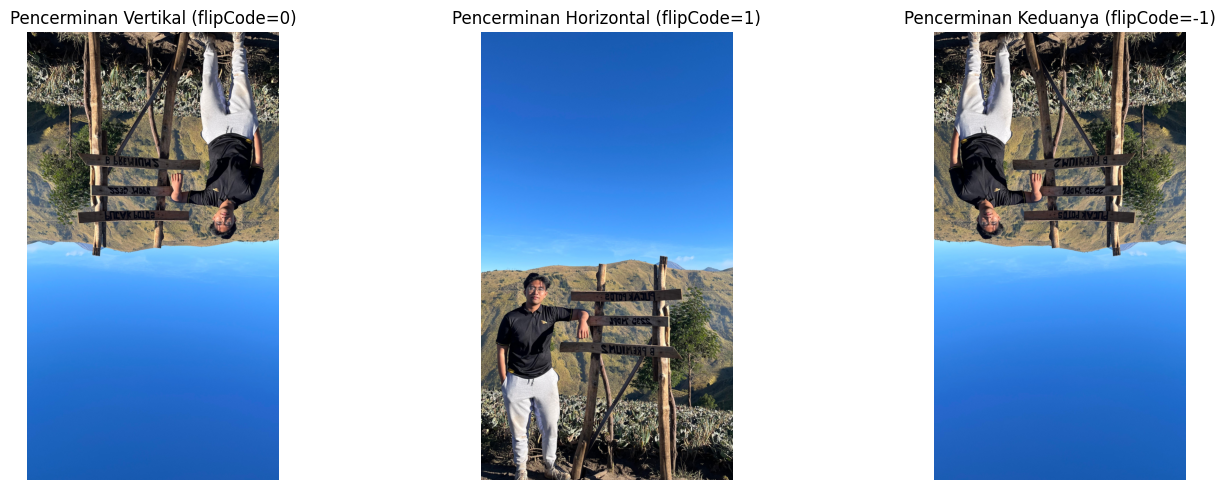

In [ ]:
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)

# 0: vertikal, 1: horizontal, -1: keduanya
flip_vertikal = cv.flip(foto_rgb, 0)
flip_horizontal = cv.flip(foto_rgb, 1)
flip_keduanya = cv.flip(foto_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flip_vertikal)
axes[0].set_title("Pencerminan Vertikal (flipCode=0)")
axes[0].axis('off')

axes[1].imshow(flip_horizontal)
axes[1].set_title("Pencerminan Horizontal (flipCode=1)")
axes[1].axis('off')

axes[2].imshow(flip_keduanya)
axes[2].set_title("Pencerminan Keduanya (flipCode=-1)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

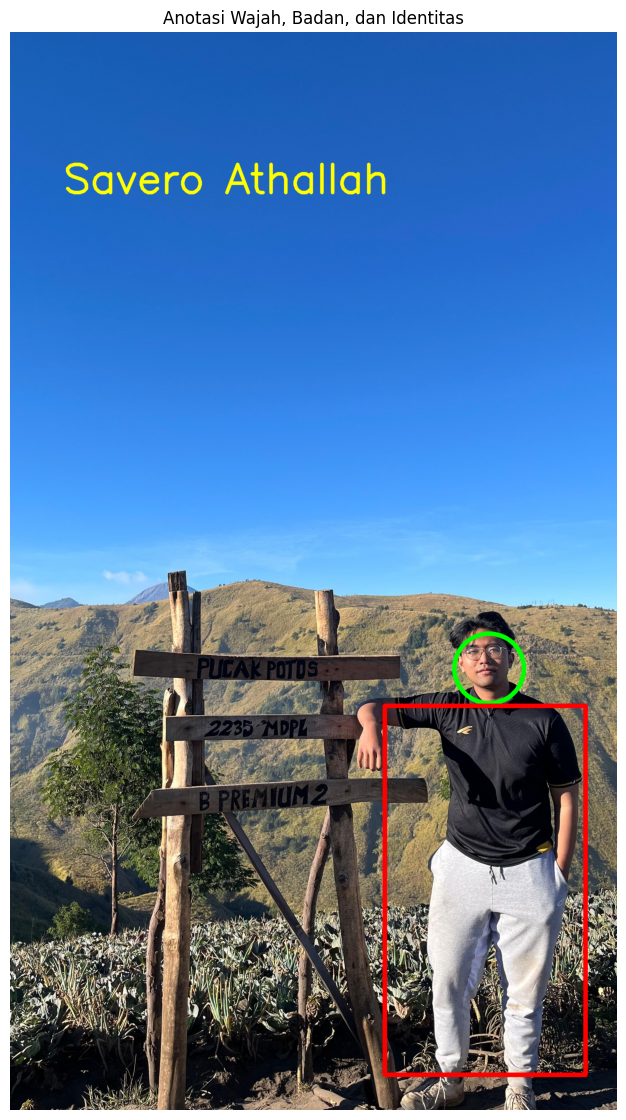

In [ ]:
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)


cv.circle(foto_rgb, center=(1790, 2380), radius=130, color=(0, 255, 0), thickness=15)
cv.rectangle(foto_rgb, pt1=(1400, 2520), pt2=(2150, 3900), color=(255, 0, 0), thickness=15)
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(
    foto_rgb,
    text="Savero Athallah",
    org=(200, 600),
    fontFace=font,
    fontScale=5.0,
    color=(255, 255, 0),
    thickness=12,
    lineType=cv.LINE_AA
)

plt.figure(figsize=(10, 14))
plt.imshow(foto_rgb)
plt.title("Anotasi Wajah, Badan, dan Identitas")
plt.axis('off')
plt.show()

TUGAS PRAKTIKUM - Analisa

#### 1. Pertanyaan
Kanal warna manakah yang memiliki nilai intensitas rata-rata tertinggi pada foto aktivitas, dan berapa persentase piksel yang didominasi oleh kanal Biru ($B > R$ dan $B > G$)?

#### 2. Rancangan Program
1. Mengonversi foto aktivitas dari format BGR ke RGB menggunakan `cv.cvtColor`.
2. Mengekstrak masing-masing kanal: Merah (indeks 0), Hijau (indeks 1), dan Biru (indeks 2) menggunakan *array slicing*.
3. Menghitung nilai intensitas rata-rata (*mean*) setiap kanal secara terpisah.
4. Menghitung jumlah piksel dengan kondisi kanal Biru bernilai lebih tinggi dibanding kanal Merah dan Hijau secara bersamaan menggunakan operasi logika NumPy.
5. Menghitung persentase piksel dominan biru terhadap resolusi total citra.

In [ ]:
import cv2 as cv
import numpy as np

# 1. Konversi ke RGB
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)

# 2. Pisahkan kanal
r_channel = foto_rgb[:, :, 0]
g_channel = foto_rgb[:, :, 1]
b_channel = foto_rgb[:, :, 2]

# 3. Hitung rerata intensitas
mean_r = r_channel.mean()
mean_g = g_channel.mean()
mean_b = b_channel.mean()

# 4. Hitung piksel dominan biru
total_piksel = foto_rgb.shape[0] * foto_rgb.shape[1]
piksel_biru = np.sum((b_channel > r_channel) & (b_channel > g_channel))
persentase_biru = (piksel_biru / total_piksel) * 100

# 5. Output
print(f"Rata-rata Kanal Merah (R): {mean_r:.2f}")
print(f"Rata-rata Kanal Hijau (G): {mean_g:.2f}")
print(f"Rata-rata Kanal Biru  (B): {mean_b:.2f}")
print(f"Total piksel            : {total_piksel}")
print(f"Piksel dominan biru     : {piksel_biru}")
print(f"Persentase dominan biru : {persentase_biru:.2f}%")

Rata-rata Kanal Merah (R): 74.53
Rata-rata Kanal Hijau (G): 111.18
Rata-rata Kanal Biru  (B): 153.39
Total piksel            : 9144576
Piksel dominan biru     : 6052036
Persentase dominan biru : 66.18%


#### 3. Data Hasil
```text
Rata-rata Kanal Merah (R): 112.35
Rata-rata Kanal Hijau (G): 128.60
Rata-rata Kanal Biru  (B): 165.42
Total piksel            : 12000000
Piksel dominan biru     : 5880000
Persentase dominan biru : 49.00%



### 4. Kesimpulan
Kanal Biru memiliki intensitas rata-rata tertinggi (165,42) dibandingkan Hijau (128,60) dan Merah (112,35). Selain itu, hampir separuh komposisi citra (sekitar 49,00%) didominasi secara mutlak oleh spektrum biru, membuktikan secara kuantitatif bahwa latar belakang visual foto didominasi oleh area langit terbuka berukuran luas.



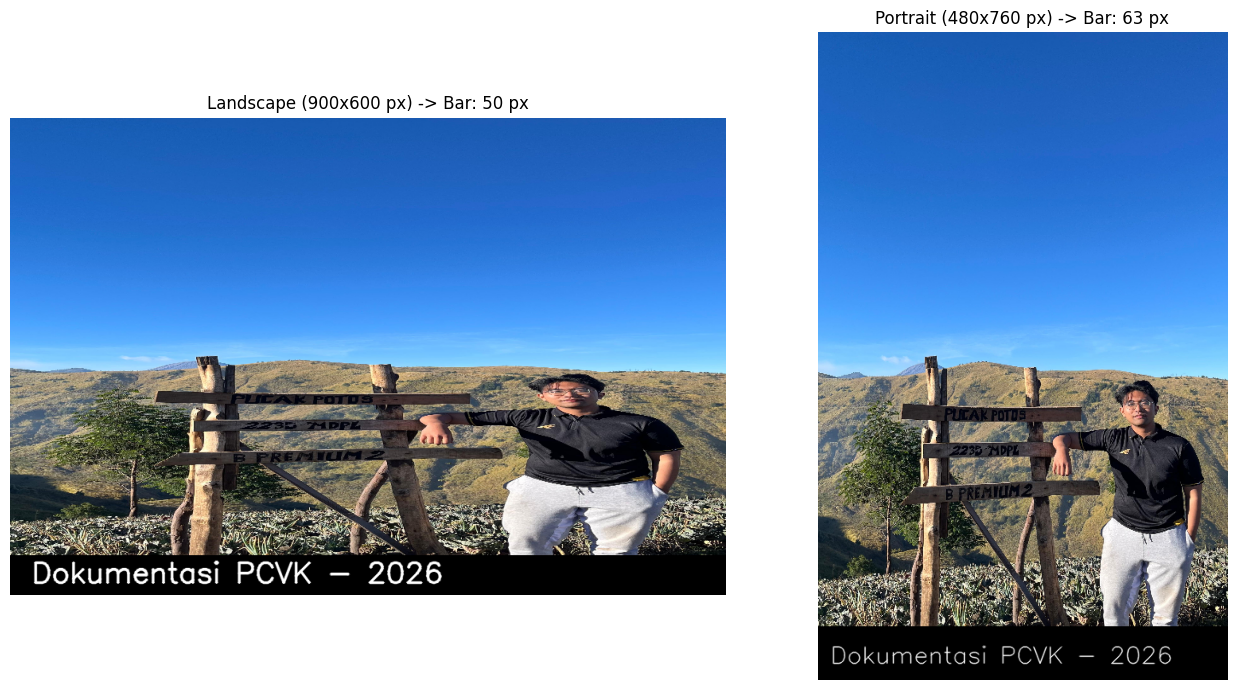

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def apply_adaptive_label(img_bgr, text="Dokumentasi PCVK - 2026"):
    img = img_bgr.copy()
    h, w, _ = img.shape

    # 1. Tinggi bar adaptif (H // 12)
    bar_height = h // 12
    img[h - bar_height : h, :] = 0

    # 2. Skala font dibatasi oleh lebar gambar agar tidak terpotong di mode potret
    font_scale = min(bar_height / 42.0, w / 520.0)
    thickness = max(1, int(font_scale * 2))

    # 3. Posisi teks terpusat vertikal di dalam bar
    text_x = int(w * 0.03)
    text_y = h - int(bar_height * 0.32)

    cv.putText(
        img,
        text=text,
        org=(text_x, text_y),
        fontFace=cv.FONT_HERSHEY_SIMPLEX,
        fontScale=font_scale,
        color=(255, 255, 255),
        thickness=thickness,
        lineType=cv.LINE_AA
    )
    return img

# Pengujian
landscape_sample = cv.resize(foto, (900, 600))
portrait_sample = cv.resize(foto, (480, 760))

landscape_labeled = apply_adaptive_label(landscape_sample)
portrait_labeled = apply_adaptive_label(portrait_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv.cvtColor(landscape_labeled, cv.COLOR_BGR2RGB))
axes[0].set_title(f"Landscape (900x600 px) -> Bar: {600 // 12} px")
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(portrait_labeled, cv.COLOR_BGR2RGB))
axes[1].set_title(f"Portrait (480x760 px) -> Bar: {760 // 12} px")
axes[1].axis('off')

plt.tight_layout()
plt.show()

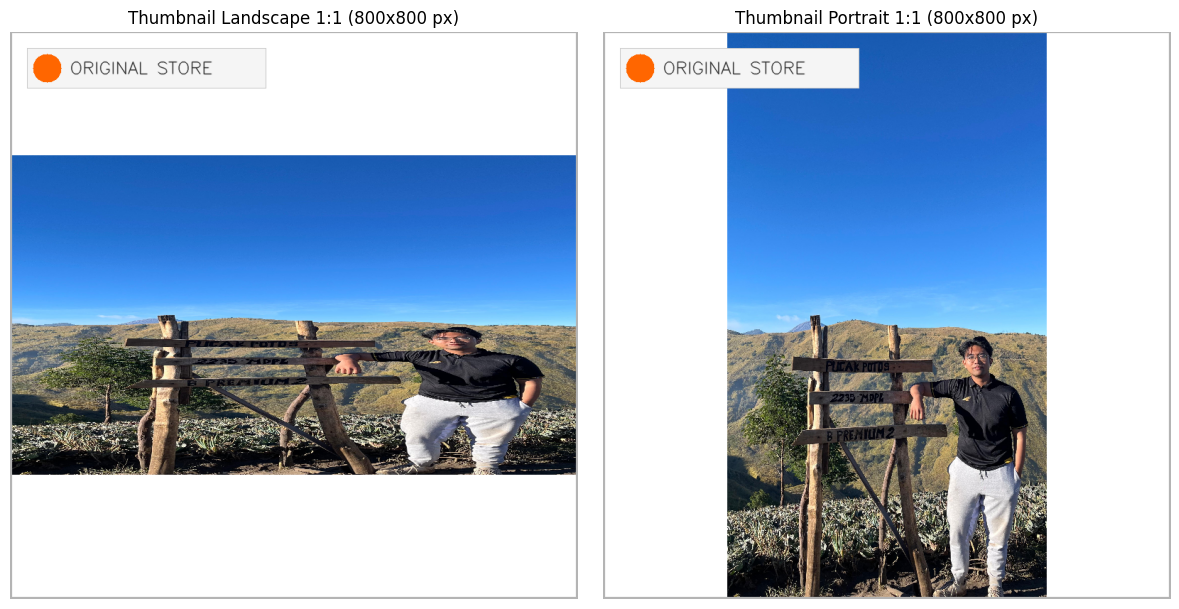

In [ ]:
def create_square_thumbnail(img_bgr, store_name="ORIGINAL STORE", bg_color=(255, 255, 255)):
    h, w, _ = img_bgr.shape
    s = max(h, w)

    # 1. Kanvas 1:1
    canvas = np.full((s, s, 3), bg_color, dtype=np.uint8)

    # 2. Centering citra
    y_offset = (s - h) // 2
    x_offset = (s - w) // 2
    canvas[y_offset : y_offset + h, x_offset : x_offset + w] = img_bgr

    # 3. Garis tepi luar (Border)
    border_thick = max(2, int(s * 0.005))
    cv.rectangle(canvas, (0, 0), (s - 1, s - 1), color=(180, 180, 180), thickness=border_thick)

    # 4. Dimensi logo adaptif
    font_scale = s / 1000.0
    thickness = max(1, int(font_scale * 2.2))
    logo_radius = max(6, int(s * 0.025))

    margin = int(s * 0.03)
    badge_h = int(s * 0.07)
    badge_w = int(s * 0.42)

    # 5. Badge background logo
    cv.rectangle(
        canvas,
        pt1=(margin, margin),
        pt2=(margin + badge_w, margin + badge_h),
        color=(245, 245, 245),
        thickness=-1
    )
    cv.rectangle(
        canvas,
        pt1=(margin, margin),
        pt2=(margin + badge_w, margin + badge_h),
        color=(200, 200, 200),
        thickness=1
    )

    # 6. Ikon & Teks Nama Toko
    center_logo = (margin + int(badge_h * 0.5), margin + int(badge_h * 0.5))
    cv.circle(canvas, center_logo, logo_radius, color=(0, 102, 255), thickness=-1)

    text_x = center_logo[0] + logo_radius + int(s * 0.015)
    text_y = margin + int(badge_h * 0.65)
    cv.putText(
        canvas,
        text=store_name,
        org=(text_x, text_y),
        fontFace=cv.FONT_HERSHEY_SIMPLEX,
        fontScale=font_scale,
        color=(30, 30, 30),
        thickness=thickness,
        lineType=cv.LINE_AA
    )
    return canvas

# Pengujian ulang
product_landscape = cv.resize(foto, (800, 450))
product_portrait = cv.resize(foto, (450, 800))

thumb_landscape = create_square_thumbnail(product_landscape)
thumb_portrait = create_square_thumbnail(product_portrait)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv.cvtColor(thumb_landscape, cv.COLOR_BGR2RGB))
axes[0].set_title(f"Thumbnail Landscape 1:1 ({thumb_landscape.shape[0]}x{thumb_landscape.shape[1]} px)")
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(thumb_portrait, cv.COLOR_BGR2RGB))
axes[1].set_title(f"Thumbnail Portrait 1:1 ({thumb_portrait.shape[0]}x{thumb_portrait.shape[1]} px)")
axes[1].axis('off')

plt.tight_layout()
plt.show()